In [ ]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyvista as pv
import time
from datetime import datetime
from gravity_forward_numba import gsphere, VecWerSch_numba, rotate_vec_ten_ecef2ned

In [ ]:
# Earth parameters (all in km and kg/m³)
R_earth = 6371.393     # mean Earth radius [km]
rho_earth = 5520.0     # mean Earth density [kg/m³]

# Sphere to model: homogeneous Earth
xc, yc, zc = 0.0, 0.0, 0.0
a = R_earth
rho = rho_earth

# Observation altitudes above Earth surface (in km!)
altitudes = [0.001, 1.0, 10.0, 100.0]  # now explicitly in km
obs_radii = [R_earth + h for h in altitudes]

# Create observation points on spherical shells (lat/lon grid)
dlat = dlon = 2.0  # degrees
lat_vals = np.arange(-90, 90 + dlat, dlat)
lon_vals = np.arange(-180, 180, dlon)

# Observation grid size (same for all altitudes)
nlat_obs = len(lat_vals)
nlon_obs = len(lon_vals)
N_obs = nlat_obs * nlon_obs
print(f"\nObservation grid: {nlat_obs} lat x {nlon_obs} lon = {N_obs} points per altitude\n")

# Store observation point arrays per altitude
P_list = []
ref_arrays_list = []  # list of lists per altitude

for r_obs in obs_radii:
    lon_grid, lat_grid = np.meshgrid(lon_vals, lat_vals)
    lon_rad = np.deg2rad(lon_grid.ravel())
    lat_rad = np.deg2rad(lat_grid.ravel())
    
    x_obs = r_obs * np.cos(lat_rad) * np.cos(lon_rad)  # in km
    y_obs = r_obs * np.cos(lat_rad) * np.sin(lon_rad)
    z_obs = r_obs * np.sin(lat_rad)
    
    P = np.column_stack((x_obs, y_obs, z_obs))
    P_list.append(P)
    
    # Analytical solution for full sphere (Earth)
    V_ref, gx_ref, gy_ref, gz_ref, Txx_ref, Txy_ref, Txz_ref, Tyy_ref, Tyz_ref, Tzz_ref = \
        gsphere(x_obs, y_obs, z_obs, xc, yc, zc, a, rho)
    
    # Transform reference arrays to NED
    gN_ref, gE_ref, gD_ref, TNN_ref, TNE_ref, TND_ref, TEE_ref, TED_ref, TDD_ref = \
        rotate_vec_ten_ecef2ned(
            lon_rad, lat_rad,
            gx_ref, gy_ref, gz_ref,
            Txx_ref, Txy_ref, Txz_ref,
            Tyy_ref, Tyz_ref, Tzz_ref
        )
    
    ref_arrays_list.append([V_ref, gN_ref, gE_ref, gD_ref,
                            TNN_ref, TNE_ref, TND_ref, TEE_ref, TED_ref, TDD_ref])

fields = ['V', 'gN', 'gE', 'gD', 'TNN', 'TNE', 'TND', 'TEE', 'TED', 'TDD']

# Refinement settings
nsub_max = 8
NSUBs = np.arange(nsub_max)

# Geographic resolution rules
Lon_Res = 5 * (2 ** NSUBs)
Lat_Res = (2 ** (NSUBs + 1)) + 2

# Containers for results per altitude
all_err_ico = []
all_err_geo = []
all_time_ico = []
all_time_geo = []

# Containers for reference values per altitude
ref_values = []


Observation grid: 91 lat x 180 lon = 16380 points per altitude



In [ ]:
# Loop over each altitude
for alt_idx, (P, ref_arrays) in enumerate(zip(P_list, ref_arrays_list)):
    h_km = altitudes[alt_idx]
    print(f"\n=== Altitude: {h_km:g} km ===")
    
    err_ico = {f: [] for f in fields}
    err_geo = {f: [] for f in fields}
    time_ico = []
    time_geo = []
    
    x_obs, y_obs, z_obs = P[:,0], P[:,1], P[:,2]
    r_obs = np.sqrt(x_obs**2 + y_obs**2 + z_obs**2)
    lat_rad = np.arcsin(z_obs / r_obs)
    lon_rad = np.arctan2(y_obs, x_obs)
    
    for idx, nsub in enumerate(NSUBs):
        print(f"  Processing nsub = {nsub}... [{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}]")
        
        # --- Icosphere ---
        mesh_ico = pv.Icosphere(radius=a, center=(xc, yc, zc), nsub=nsub)
        verts_ico = mesh_ico.points  # in km
        faces_ico = mesh_ico.regular_faces

        t0 = time.time()
        V_i, gx_i, gy_i, gz_i, Txx_i, Txy_i, Txz_i, Tyy_i, Tyz_i, Tzz_i = \
            VecWerSch_numba(P, verts_ico, faces_ico, rho)
        t_ico = time.time() - t0
        time_ico.append(t_ico)
        
        # Transform numerical results to NED
        gN_ico, gE_ico, gD_ico, TNN_ico, TNE_ico, TND_ico, TEE_ico, TED_ico, TDD_ico = \
            rotate_vec_ten_ecef2ned(
                lon_rad, lat_rad,
                gx_i, gy_i, gz_i,
                Txx_i, Txy_i, Txz_i,
                Tyy_i, Tyz_i, Tzz_i
            )
        
        cal_ico = [V_i, gN_ico, gE_ico, gD_ico,
                   TNN_ico, TNE_ico, TND_ico, TEE_ico, TED_ico, TDD_ico]
        
        for field, ref, cal in zip(fields, ref_arrays, cal_ico):
            rms_ref = np.linalg.norm(ref)/np.sqrt(ref.size)
            rms_cal = np.linalg.norm(cal)/np.sqrt(cal.size)
            rms_dif = np.linalg.norm(cal - ref)/np.sqrt(cal.size)
            if rms_ref < 1.e-8:
                err = rms_dif
            else:
                err = rms_dif / rms_ref
            err_ico[field].append(err)

        # --- Geographic Grid ---
        theta_res = Lon_Res[idx]
        phi_res   = Lat_Res[idx]
        mesh_geo = pv.Sphere(radius=a, center=(xc, yc, zc),
                             theta_resolution=theta_res,
                             phi_resolution=phi_res)
        verts_geo = mesh_geo.points  # in km
        faces_geo = mesh_geo.regular_faces

        t0 = time.time()
        V_g, gx_g, gy_g, gz_g, Txx_g, Txy_g, Txz_g, Tyy_g, Tyz_g, Tzz_g = \
            VecWerSch_numba(P, verts_geo, faces_geo, rho)
        t_geo = time.time() - t0
        time_geo.append(t_geo)
        
        # Transform numerical results to NED
        gN_geo, gE_geo, gD_geo, TNN_geo, TNE_geo, TND_geo, TEE_geo, TED_geo, TDD_geo = \
            rotate_vec_ten_ecef2ned(
                lon_rad, lat_rad,
                gx_g, gy_g, gz_g,
                Txx_g, Txy_g, Txz_g,
                Tyy_g, Tyz_g, Tzz_g
            )
        
        cal_geo = [V_g, gN_geo, gE_geo, gD_geo,
                   TNN_geo, TNE_geo, TND_geo, TEE_geo, TED_geo, TDD_geo]
        
        for field, ref, cal in zip(fields, ref_arrays, cal_geo):
            rms_ref = np.linalg.norm(ref)/np.sqrt(ref.size)
            rms_cal = np.linalg.norm(cal)/np.sqrt(cal.size)
            rms_dif = np.linalg.norm(cal - ref)/np.sqrt(cal.size)
            if rms_ref < 1.e-8:
                err = rms_dif
            else:
                err = rms_dif / rms_ref
            err_geo[field].append(err)
    
    all_err_ico.append(err_ico)
    all_err_geo.append(err_geo)
    all_time_ico.append(time_ico)
    all_time_geo.append(time_geo)
    
    # Collect reference values for this altitude
    ref_values.append({field: np.mean(ref) for field, ref in zip(fields, ref_arrays)})


=== Altitude: 0.001 km ===
  Processing nsub = 0... [2026-01-30 19:00:56]
  Processing nsub = 1... [2026-01-30 19:00:58]
  Processing nsub = 2... [2026-01-30 19:00:58]
  Processing nsub = 3... [2026-01-30 19:00:58]
  Processing nsub = 4... [2026-01-30 19:00:59]
  Processing nsub = 5... [2026-01-30 19:00:59]
  Processing nsub = 6... [2026-01-30 19:01:01]
  Processing nsub = 7... [2026-01-30 19:01:09]

=== Altitude: 1 km ===
  Processing nsub = 0... [2026-01-30 19:01:52]
  Processing nsub = 1... [2026-01-30 19:01:52]
  Processing nsub = 2... [2026-01-30 19:01:52]
  Processing nsub = 3... [2026-01-30 19:01:53]
  Processing nsub = 4... [2026-01-30 19:01:53]
  Processing nsub = 5... [2026-01-30 19:01:54]
  Processing nsub = 6... [2026-01-30 19:01:56]
  Processing nsub = 7... [2026-01-30 19:02:04]

=== Altitude: 10 km ===
  Processing nsub = 0... [2026-01-30 19:02:51]
  Processing nsub = 1... [2026-01-30 19:02:52]
  Processing nsub = 2... [2026-01-30 19:02:52]
  Processing nsub = 3... [2026

In [ ]:
# Generate DataFrames and print tables
for i, h in enumerate(altitudes):
    df_ico = pd.DataFrame(all_err_ico[i], index=NSUBs)
    df_ico['Time (s)'] = all_time_ico[i]

    df_geo = pd.DataFrame(all_err_geo[i], index=NSUBs)
    df_geo['Time (s)'] = all_time_geo[i]

    print("\n" + "="*80)
    print(f"Altitude = {h:g} km — Icosphere vs Analytical Earth "
          f"({nlat_obs} x {nlon_obs} = {N_obs} obs pts)")
    print("="*80)
    print(df_ico.to_string(float_format="{:.2e}".format))

    print("\n" + "="*80)
    print(f"Altitude = {h:g} km — Geographic Grid vs Analytical Earth "
          f"({nlat_obs} x {nlon_obs} = {N_obs} obs pts)")
    print("="*80)
    print(df_geo.to_string(float_format="{:.2e}".format))

# Print reference values table
print("\n" + "="*80)
print("Reference Values at Different Altitudes")
print("GP in m^2/s^2, GV in mGal, GGT in Eotvos")
print("="*80)
df_refs = pd.DataFrame(ref_values, index=altitudes)
print(df_refs.to_string(float_format="{:8.2f}".format))


Altitude = 0.001 km — Icosphere vs Analytical Earth (91 x 180 = 16380 obs pts)
         V       gN       gE       gD      TNN      TNE      TND      TEE      TED      TDD  Time (s)
0 3.95e-01 1.19e+04 1.25e+04 3.96e-01 4.07e-01 7.48e+01 1.67e+02 4.14e-01 1.74e+02 4.08e-01  1.73e+00
1 1.26e-01 8.25e+03 6.68e+03 1.25e-01 4.32e-01 7.96e+01 1.99e+02 4.29e-01 1.52e+02 4.26e-01  7.83e-03
2 3.39e-02 2.75e+03 2.54e+03 3.38e-02 2.34e-01 4.80e+01 1.13e+02 2.34e-01 1.03e+02 2.31e-01  2.68e-02
3 8.62e-03 7.72e+02 7.52e+02 8.64e-03 1.15e-01 2.81e+01 6.08e+01 1.14e-01 5.92e+01 1.13e-01  1.09e-01
4 2.17e-03 1.99e+02 2.03e+02 2.17e-03 5.49e-02 1.55e+01 3.22e+01 5.47e-02 3.23e+01 5.37e-02  2.68e-01
5 5.42e-04 5.28e+01 5.48e+01 5.40e-04 2.60e-02 8.10e+00 1.76e+01 2.60e-02 1.69e+01 2.54e-02  8.90e-01
6 1.36e-04 1.29e+01 1.29e+01 1.37e-04 1.23e-02 4.30e+00 8.52e+00 1.24e-02 8.19e+00 1.20e-02  3.78e+00
7 3.39e-05 3.33e+00 3.40e+00 3.40e-05 5.88e-03 2.08e+00 4.36e+00 5.93e-03 4.35e+00 5.68e-03  2.17e+01

A

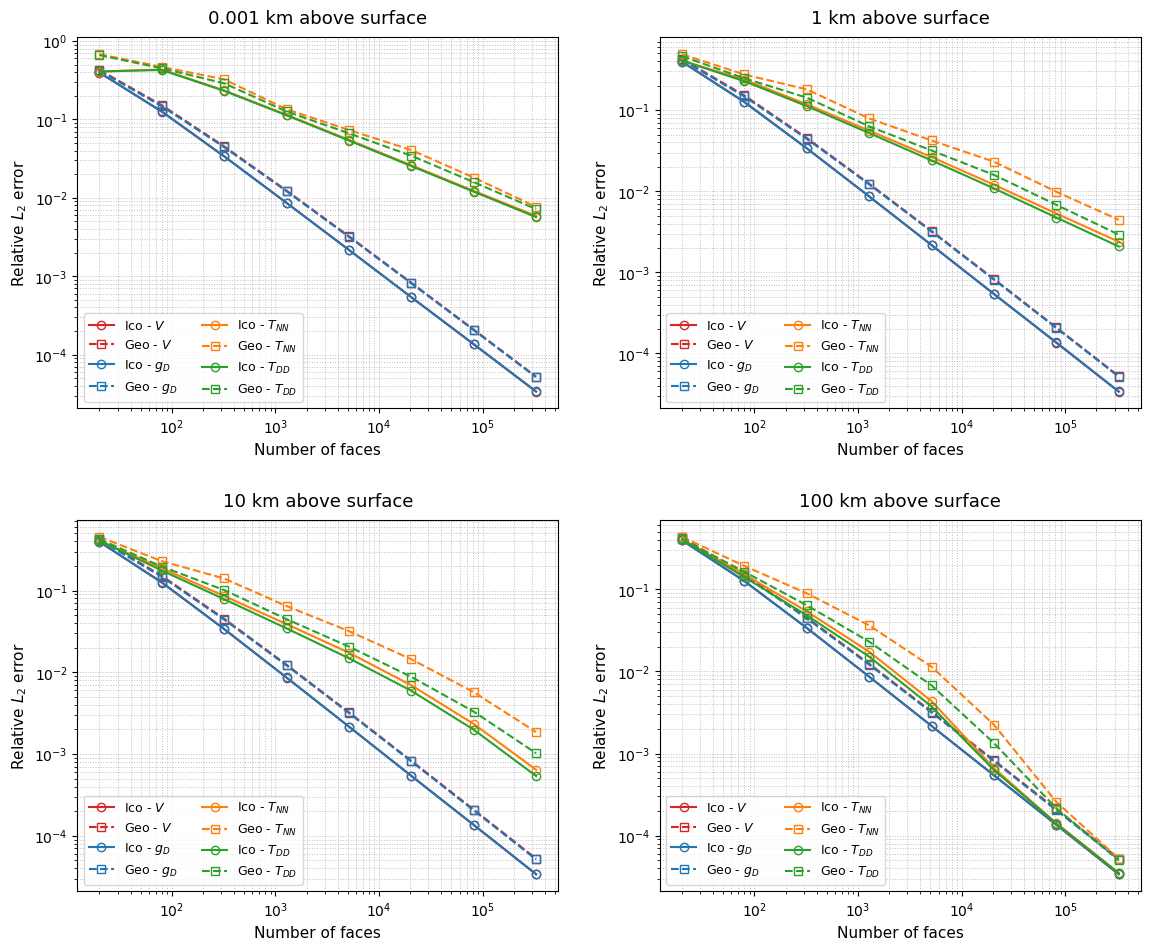

In [ ]:
# Plot representative fields for each altitude
rep_fields = ['V', 'gD', 'TNN', 'TDD']
latex_labels = {'V': r'$V$', 'gD': r'$g_D$', 'TNN': r'$T_{NN}$', 'TDD': r'$T_{DD}$'}
colors = {'V': 'tab:red', 'gD': 'tab:blue', 'TNN': 'tab:orange', 'TDD': 'tab:green'}

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.flatten()

N_faces = 20 * (4 ** NSUBs)

for i, h in enumerate(altitudes):
    ax = axs[i]
    
    # Plot each field
    for field in rep_fields:
        label_latex = latex_labels[field]
        color = colors[field]
        
        # Icosphere
        ax.loglog(
            N_faces, all_err_ico[i][field],
            linestyle='-', marker='o', fillstyle='none',
            color=color, linewidth=1.5, markersize=6,
            label=f'Ico - {label_latex}'
        )
        # Geographic grid
        ax.loglog(
            N_faces, all_err_geo[i][field],
            linestyle='--', marker='s', fillstyle='none',
            color=color, linewidth=1.5, markersize=6,
            label=f'Geo - {label_latex}'
        )
    
    ax.set_title(f'{h:g} km above surface', fontsize=13, pad=10)
    ax.set_xlabel('Number of faces', fontsize=11)
    ax.set_ylabel('Relative $L_2$ error', fontsize=11)
    ax.grid(True, which="both", linestyle=':', linewidth=0.7, alpha=0.8)
    ax.legend(fontsize=9, loc='lower left', 
              frameon=True, fancybox=True, shadow=False, ncol=2)

plt.tight_layout(pad=2.5)
plt.savefig("IcoGeoSphere_Rs.png", dpi=300, bbox_inches='tight')
plt.show()